# Double Machine Learning on Crypto Premium Index with Regime Conditioning

**Chapter 15: Causal Estimation with ML**
**Docker image**: `ml4t`

**Book Reference**: Chapter 15, §15.2 (DML with Regime Heterogeneity)

This notebook applies Double Machine Learning (DML) to estimate the causal effect
of the premium index (perpetual - spot / spot) on forward returns, conditioned
on market regime.

The estimand is the marginal effect of a one-unit change in the 14-day
premium z-score on the next-bar return, after adjustment for observed
pre-treatment controls:

$$\theta = \frac{\partial}{\partial t}\, E[Y(t)] \bigm|_{t = \text{premium z-score}}$$

Regime-specific estimates apply this same estimand within volatility strata
(subgroup ATEs), not Conditional Average Treatment Effects (CATE), which
would require a single heterogeneity model rather than separate
regime-stratified fits.

## Causal Design Contract

| Element                   | This notebook                                                                                          |
|---------------------------|--------------------------------------------------------------------------------------------------------|
| Unit                      | Crypto-symbol × 8-hour-bar from the crypto perps panel (19 symbols)                                    |
| Treatment                 | `premium_zscore_14d` (continuous)                                                                       |
| Outcome                   | `fwd_ret_8h` (next-bar return)                                                                          |
| Controls (W in EconML)    | `price_vol_14d`, `funding_rate`, `premium_dev_mean_14d`, `premium_vol_72h`, `vol_ratio_short`, `premium_persistence_7d` |
| Effect modifiers (X)      | Volatility regime (high vs low), entered via regime-stratified DML and a single-model HAC interaction |
| Identification assumption | Selection on observables given the six controls; controls are constructed strictly pre-treatment       |
| Main failure modes        | Bad-control bias from premium-derived controls; mistimed treatment relative to control horizons; cross-symbol contagion that the controls don't capture |
| Estimand                  | Marginal effect of a one-unit z-score change; ATE within each volatility regime; interaction coefficient on T × regime |

**Learning Outcomes**:
- Apply DML to crypto premium index returns with HAC standard errors
- Estimate regime-conditional treatment effects (high-vol vs low-vol)
- Validate causal effects with block permutation refutation tests

**Methodological Notes** (per Chernozhukov et al. 2017):
- **WalkForwardCV**: Cross-fitting with purging and embargo
- **HAC Standard Errors**: Newey-West correction for autocorrelated residuals
- **Block Permutation**: Refutation tests preserve autocorrelation structure

**Timing Protocol (Critical for Causal Validity)**:
- Confounders: computed from pre-computed features (strictly pre-treatment)
- Treatment: premium_zscore_14d at t
- Outcome: fwd_ret_8h (forward-looking)

**Cross-References**:
- Chapter 15: [`03_econml_dml`](03_econml_dml.ipynb) (ETF momentum DML)
- Chapter 8: Crypto premium features
- Chapter 14: Latent factor regime detection

**Prerequisites**: [`03_econml_dml`](03_econml_dml.ipynb) for DML methodology;
crypto premium data from Ch2 data pipeline

## 1. Setup and Imports

In [1]:
"""Double Machine Learning on Crypto Premium Index with Regime Conditioning: estimate regime-conditional causal effects."""

import warnings

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from IPython.display import display
from ml4t.diagnostic.splitters import WalkForwardCV
from plotly.subplots import make_subplots
from sklearn.ensemble import GradientBoostingRegressor

import utils.style  # noqa: F401  # registers + activates the ml4t Plotly template
from case_studies.utils.causal import (
    block_permute,
    empirical_permutation_p,
    manual_dml_timeseries,
)
from utils.modeling import load_modeling_dataset
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

warnings.filterwarnings("ignore")

# Statsmodels for HAC standard errors
import statsmodels.api as sm
from econml.dml import LinearDML
from statsmodels.regression.linear_model import OLS

In [2]:
# Configuration - readers can modify these
CASE_STUDY_ID = "crypto_perps_funding"
PRIMARY_LABEL = "fwd_ret_8h"
MAX_SYMBOLS = 0
SEED = 42
CV_FOLDS = 5
MAX_SAMPLES = 30000  # Temporal subsample if dataset too large

# Cross-validation parameters
EMBARGO_PERIODS = 3  # 3 bars = 24h embargo for 8h bars
EMBARGO_PCT = 0.01

# Refutation parameters
N_PLACEBO_PERMUTATIONS = 100
# Block-permutation sizes (in 8h bars). Sweep over 1-day / 7-day / 14-day
# blocks so the placebo preserves the autocorrelation induced by the
# 14-day premium z-score treatment rather than only short-range structure.
BLOCK_SIZES = [3, 21, 42]
BLOCK_SIZE_HEADLINE = 21  # headline test uses 7-day blocks (one treatment half-life)

In [3]:
set_global_seeds(SEED)

print("DML Crypto Premium Index Configuration:")
print(f"  Case study: {CASE_STUDY_ID}")
print(f"  Label: {PRIMARY_LABEL}")
print(f"  CV Folds: {CV_FOLDS}")
print(f"  Embargo: {EMBARGO_PERIODS} bars (24h)")

DML Crypto Premium Index Configuration:
  Case study: crypto_perps_funding
  Label: fwd_ret_8h
  CV Folds: 5
  Embargo: 3 bars (24h)


## 2. Load Pre-Computed Features from Modeling Pipeline

We use `load_modeling_dataset()` to load pre-computed premium features (Ch8)
and labels, joined and ready for analysis. This replaces manual OHLCV loading
and confounder engineering. Real-data only; no synthetic fallback. If the
modeling dataset is missing, the notebook fails loudly rather than silently
switching to a synthetic substitute.

In [4]:
# Real-data only; load failure is a fatal error.
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)

treatment_col = "premium_zscore_14d"
confounder_cols = [
    "price_vol_14d",
    "funding_rate",
    "premium_dev_mean_14d",
    "premium_vol_72h",
    "vol_ratio_short",
    "premium_persistence_7d",
]

available = set(mds.dataset.columns)
missing = [c for c in [treatment_col] + confounder_cols if c not in available]
if missing:
    raise RuntimeError(
        f"Required columns missing from modeling dataset "
        f"{CASE_STUDY_ID}/{PRIMARY_LABEL}: {missing}. "
        f"Available features: {mds.feature_names[:20]}... "
        f"Rebuild the Ch8 features pipeline for case study '{CASE_STUDY_ID}'."
    )

In [5]:
# Build analysis DataFrame from loaded features
outcome_col = mds.label_col
date_col = mds.date_col

analysis_cols = [date_col] + mds.entity_cols + [treatment_col, outcome_col] + confounder_cols
df = (
    mds.dataset.select([c for c in analysis_cols if c in available])
    .drop_nulls()
    .sort(date_col)
    .to_pandas()
)

if len(df) > MAX_SAMPLES:
    # Subsample to MAX_SAMPLES most recent unique timestamps, never cutting
    # through a cross-section. On a stacked multi-symbol panel the row-level
    # iloc tail would leave a fragmented final timestamp.
    rows_per_ts = df.groupby(date_col).size().median()
    n_ts = int(np.ceil(MAX_SAMPLES / max(rows_per_ts, 1)))
    keep_ts = df[date_col].drop_duplicates().iloc[-n_ts:]
    df = df[df[date_col].isin(keep_ts)].reset_index(drop=True)
    print(
        f"Taking most recent {n_ts} timestamps ({len(df):,} rows) "
        f"from {len(keep_ts):,} unique timestamps"
    )

# Volatility regime: market-wide per timestamp (NOT a rolling median over the
# stacked panel). On a multi-symbol panel a row-level rolling median mixes
# cross-sectional and temporal variation and silently changes the regime
# threshold whenever the symbol composition shifts. We compute the
# cross-sectional median vol per timestamp, then a rolling-median threshold
# *shifted by 1 bar* so the regime label is known before the treated return
# interval, a strictly pre-treatment construction.
market_vol = (
    df.groupby(date_col)["price_vol_14d"].median().sort_index().rename("market_vol").to_frame()
)
market_vol["vol_threshold"] = (
    market_vol["market_vol"].shift(1).rolling(168, min_periods=50).median()
)
market_vol["high_vol_regime"] = (market_vol["market_vol"] > market_vol["vol_threshold"]).astype(
    "Int64"
)

df = df.merge(
    market_vol[["high_vol_regime"]],
    left_on=date_col,
    right_index=True,
    how="left",
)
df = df.dropna(subset=["high_vol_regime"]).reset_index(drop=True)
df["high_vol_regime"] = df["high_vol_regime"].astype(int)

print(f"Analysis data: {df.shape[0]:,} rows")
print(f"Date range: {df[date_col].min()} to {df[date_col].max()}")
print(f"Treatment: {treatment_col}, Outcome: {outcome_col}")
print(f"Confounders: {confounder_cols}")
if "symbol" in df.columns:
    print(f"Assets: {df['symbol'].nunique()}")

Taking most recent 1765 timestamps (33,028 rows) from 1,765 unique timestamps
Analysis data: 33,028 rows
Date range: 2024-05-22 08:00:00+00:00 to 2025-12-31 08:00:00+00:00
Treatment: premium_zscore_14d, Outcome: fwd_ret_8h
Confounders: ['price_vol_14d', 'funding_rate', 'premium_dev_mean_14d', 'premium_vol_72h', 'vol_ratio_short', 'premium_persistence_7d']
Assets: 19


## 3. Define Treatment, Outcome, and Confounders

In [6]:
T = df[treatment_col].values
Y = df[outcome_col].values
X = df[confounder_cols].values
regime = df["high_vol_regime"].values

print("\nCausal Setup:")
print(f"  Treatment (T): {treatment_col}, range [{T.min():.6f}, {T.max():.6f}]")
print(f"  Outcome (Y): {outcome_col}, range [{Y.min():.4f}, {Y.max():.4f}]")
print(f"  Confounders (X): {len(confounder_cols)} variables")
print(f"  Regime: {regime.sum():,} high-vol, {(1 - regime).sum():,} low-vol")


Causal Setup:
  Treatment (T): premium_zscore_14d, range [-6.217522, 5.524236]
  Outcome (Y): fwd_ret_8h, range [-0.2789, 0.3408]
  Confounders (X): 6 variables
  Regime: 14,335 high-vol, 18,693 low-vol


## 4. Naive Estimate (Biased)

In [7]:
print("\nNaive Estimate (OLS, ignoring confounders)...")

T_with_const = np.column_stack([np.ones(len(T)), T])
naive_coef = np.linalg.lstsq(T_with_const, Y, rcond=None)[0]
naive_effect = naive_coef[1]

# IID Standard error
Y_pred_naive = T_with_const @ naive_coef
residuals = Y - Y_pred_naive
mse = np.mean(residuals**2)
se_naive_iid = np.sqrt(mse / (T.var() * len(T)))

# HAC Standard error (Newey-West)
ols_naive = OLS(Y, T_with_const).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
se_naive_hac = np.sqrt(ols_naive.cov_params()[1, 1])
t_stat_naive = naive_effect / se_naive_hac

print(f"  Naive effect: {naive_effect:.4f}")
print(f"  SE (IID): {se_naive_iid:.4f}")
print(f"  SE (HAC): {se_naive_hac:.4f}")
print(f"  SE inflation (HAC/IID): {se_naive_hac / se_naive_iid:.2f}x")
print(f"  t-stat (HAC): {t_stat_naive:.2f}")


Naive Estimate (OLS, ignoring confounders)...
  Naive effect: -0.0001
  SE (IID): 0.0001
  SE (HAC): 0.0003
  SE inflation (HAC/IID): 2.03x
  t-stat (HAC): -0.37


## 5. DML with Walk-Forward CV + Embargo

Uses shared `manual_dml_timeseries` from `utils.causal`.

In [8]:
print("\nDouble Machine Learning with walk-forward CV + embargo...")

dml_result = manual_dml_timeseries(
    Y,
    T,
    X,
    n_folds=CV_FOLDS,
    embargo=EMBARGO_PERIODS,
    return_residuals=True,
)

dml_effect = dml_result["theta"]
dml_se_iid = dml_result["se_iid"]
dml_se_hac = dml_result["se_hac"]
dml_t_stat = dml_result["t_stat_hac"]
Y_res = dml_result.get("Y_res", np.zeros_like(Y))
T_res = dml_result.get("T_res", np.zeros_like(T))

print(f"\nDML Results (walk-forward CV with {EMBARGO_PERIODS}-bar embargo):")
print(f"  DML effect: {dml_effect:.4f}")
print(f"  SE (IID): {dml_se_iid:.4f}")
print(f"  SE (HAC): {dml_se_hac:.4f}")
print(f"  SE inflation: {dml_se_hac / dml_se_iid:.2f}x")
print(f"  t-stat (HAC): {dml_t_stat:.2f}")


Double Machine Learning with walk-forward CV + embargo...



DML Results (walk-forward CV with 3-bar embargo):
  DML effect: -0.0007
  SE (IID): 0.0007
  SE (HAC): 0.0010
  SE inflation: 1.48x
  t-stat (HAC): -0.73


## 6. Compare Naive vs DML

In [9]:
bias = naive_effect - dml_effect
bias_pct = bias / abs(dml_effect) * 100 if dml_effect != 0 else 0

comparison_df = pd.DataFrame(
    {
        "Naive": [naive_effect, se_naive_hac, t_stat_naive],
        "DML": [dml_effect, dml_se_hac, dml_t_stat],
    },
    index=["Effect", "SE (HAC)", "t-stat (HAC)"],
)
display(comparison_df)

print(f"Confounding bias (naive - DML): {bias:.4f} ({bias_pct:+.1f}%)")

,Naive,DML
Effect,-0.000107,-0.000729
SE (HAC),0.000291,0.001005
t-stat (HAC),-0.366833,-0.725157


Confounding bias (naive - DML): 0.0006 (+85.3%)


## 7. Regime-Conditional Effects

**Estimand and terminology**. The target quantity in this notebook is the
marginal effect of a one-unit change in the 14-day premium z-score on the
next-bar return, after adjustment for observed pre-treatment controls:

$$
\theta = \frac{\partial}{\partial t}\, E[Y(t)] \bigm|_{t = \text{premium z-score}}
$$

Regime-specific estimates apply this same estimand within volatility
strata; these are **subgroup ATEs**, not Conditional Average Treatment
Effects (CATE). CATE refers to individual-level or covariate-conditional
heterogeneity estimated by a single model (Causal Forest, X-learner). We
repeat the estimand inside each regime rather than fitting a single
heterogeneity model.

In [10]:
print("\nRegime-Conditional Treatment Effects (Regime-Stratified ATE)...")

low_vol_mask = regime == 0
high_vol_mask = regime == 1

print("\n  Low Volatility Regime:")
if low_vol_mask.sum() > 100:
    result_low = manual_dml_timeseries(
        Y[low_vol_mask],
        T[low_vol_mask],
        X[low_vol_mask],
        n_folds=3,
        embargo=EMBARGO_PERIODS,
    )
    effect_low = result_low["theta"]
    se_low_hac = result_low["se_hac"]
    t_low = result_low["t_stat_hac"]
    print(f"    Effect: {effect_low:.4f} (t={t_low:.2f}, SE_HAC={se_low_hac:.4f})")
else:
    effect_low, se_low_hac, t_low = 0, 1, 0
    print("    Insufficient data")

print("\n  High Volatility Regime:")
if high_vol_mask.sum() > 100:
    result_high = manual_dml_timeseries(
        Y[high_vol_mask],
        T[high_vol_mask],
        X[high_vol_mask],
        n_folds=3,
        embargo=EMBARGO_PERIODS,
    )
    effect_high = result_high["theta"]
    se_high_hac = result_high["se_hac"]
    t_high = result_high["t_stat_hac"]
    print(f"    Effect: {effect_high:.4f} (t={t_high:.2f}, SE_HAC={se_high_hac:.4f})")
else:
    effect_high, se_high_hac, t_high = 0, 1, 0
    print("    Insufficient data")


Regime-Conditional Treatment Effects (Regime-Stratified ATE)...

  Low Volatility Regime:
    Effect: 0.0007 (t=0.59, SE_HAC=0.0011)

  High Volatility Regime:


    Effect: -0.0020 (t=-1.12, SE_HAC=0.0017)


In [11]:
# Naive regime difference: independence-of-subsets approximation.
# This is fast and intuitive but assumes the two subset estimates are
# independent draws; they are not, even though the subsets are disjoint,
# because they come from the same market environment and the residualized
# DML residuals carry shared variance.
effect_diff = effect_high - effect_low
se_diff_independent = np.sqrt(se_low_hac**2 + se_high_hac**2)
t_diff_independent = effect_diff / se_diff_independent if se_diff_independent > 0 else 0

print(f"\n  Regime Difference (independence approximation): {effect_diff:.4f}")
print(f"    SE: {se_diff_independent:.4f}, t={t_diff_independent:.2f}")

# Cleaner regime difference: single interaction model fitted on the full
# sample. The coefficient on T_res × high_vol on residualized data is the
# regime interaction; the HAC standard error comes from the joint OLS. The
# regime main effect is included so the interaction is identified against
# regime-specific intercepts rather than absorbing a regime mean shift.
keep = ~np.isnan(T_res) & ~np.isnan(Y_res)
T_res_int = T_res[keep]
Y_res_int = Y_res[keep]
regime_int = regime[keep]

if len(T_res_int) > 100:
    interaction_design = np.column_stack(
        [
            np.ones(len(T_res_int)),
            regime_int,
            T_res_int,
            T_res_int * regime_int,
        ]
    )
    interaction_model = OLS(Y_res_int, interaction_design).fit(
        cov_type="HAC", cov_kwds={"maxlags": 12}
    )
    interaction_effect = float(interaction_model.params[3])
    interaction_se = float(interaction_model.bse[3])
    interaction_t = float(interaction_model.tvalues[3])
    interaction_p = float(interaction_model.pvalues[3])

    print(f"\n  Regime Interaction (HAC, single model): {interaction_effect:.4f}")
    print(f"    SE: {interaction_se:.4f}, t={interaction_t:.2f}, p={interaction_p:.3f}")
    t_diff = interaction_t
    se_diff = interaction_se
else:
    interaction_effect = interaction_se = interaction_t = interaction_p = float("nan")
    t_diff = t_diff_independent
    se_diff = se_diff_independent

if abs(t_diff) > 1.96:
    print("  -> Significant heterogeneity by regime")
else:
    print("  -> No significant heterogeneity")


  Regime Difference (independence approximation): -0.0026
    SE: 0.0021, t=-1.27

  Regime Interaction (HAC, single model): -0.0023
    SE: 0.0019, t=-1.18, p=0.238
  -> No significant heterogeneity


## 8. EconML Comparison (if available)

In [12]:
print("\nEconML LinearDML Comparison...")

T_reshaped = T.reshape(-1, 1)

cv = WalkForwardCV(
    n_splits=CV_FOLDS,
    label_horizon=EMBARGO_PERIODS,
    embargo_pct=EMBARGO_PCT,
    expanding=True,
)

linear_dml = LinearDML(
    model_y=GradientBoostingRegressor(n_estimators=50, max_depth=3, random_state=42),
    model_t=GradientBoostingRegressor(n_estimators=50, max_depth=3, random_state=42),
    cv=cv,
    random_state=42,
)
# Confounders enter via W (controls used for residualization). The regime
# variable would be the natural X (effect modifier) for a single-model
# heterogeneous-effects fit; we keep the regime split as a separate stratified
# DML above to keep the comparison with the manual DML apples-to-apples.
linear_dml.fit(Y, T_reshaped, W=X)

econml_effect = float(linear_dml.ate())
ci_lower, ci_upper = (float(v) for v in linear_dml.ate_interval(alpha=0.05))

print(f"  EconML effect: {econml_effect:.4f}")
print(f"  95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"  Manual DML effect: {dml_effect:.4f}")
print(f"  Difference: {abs(econml_effect - dml_effect):.6f}")


EconML LinearDML Comparison...


  EconML effect: -0.0001
  95% CI: [-0.0014, 0.0012]
  Manual DML effect: -0.0007
  Difference: 0.000655


## 9. Refutation Tests

**Block Permutation**: We shuffle treatment in BLOCKS to preserve
autocorrelation structure. Simple random permutation destroys the
time-series structure and gives false confidence.

Because the treatment is a 14-day premium z-score and several controls
use multi-day windows, a 3-bar (24h) block preserves only short-range
autocorrelation. We sweep block sizes of 3, 21, 42 bars (1d / 7d / 14d)
and check whether the placebo conclusion changes with block length.

In [13]:
block_sweep_rows = []

for block_size in BLOCK_SIZES:
    print(
        f"\n  Block size {block_size} bars "
        f"({block_size * 8 // 24}d): {N_PLACEBO_PERMUTATIONS} permutations..."
    )
    placebo_effects_block = []
    rng = np.random.default_rng(SEED)

    for _ in range(N_PLACEBO_PERMUTATIONS):
        T_placebo = block_permute(T, block_size, rng=rng)
        perm_result = manual_dml_timeseries(
            Y,
            T_placebo,
            X,
            n_folds=3,
            embargo=EMBARGO_PERIODS,
        )
        if not np.isnan(perm_result["theta"]):
            placebo_effects_block.append(perm_result["theta"])

    if len(placebo_effects_block) >= 10:
        p_mean = float(np.mean(placebo_effects_block))
        p_std = float(np.std(placebo_effects_block))
        z = (dml_effect - p_mean) / p_std if p_std > 0 else np.inf
        # The plus-one-corrected permutation p-value, not a false discovery rate.
        # The pass criterion below asks for p < 0.05, so with fewer than 19 placebo
        # draws the floor of 1 / (n + 1) is already above it and no configuration
        # can pass - which is the honest answer at that resolution.
        block_p = empirical_permutation_p(np.asarray(placebo_effects_block), dml_effect)
        passes = abs(z) > 2 and block_p < 0.05
    else:
        p_mean = p_std = z = block_p = float("nan")
        passes = False

    block_sweep_rows.append(
        {
            "block_size": block_size,
            "n_successful": len(placebo_effects_block),
            "placebo_mean": p_mean,
            "placebo_std": p_std,
            "z_score": z,
            "permutation_p": block_p,
            "passes": passes,
        }
    )

block_sweep_df = pd.DataFrame(block_sweep_rows).set_index("block_size")
print("\nBlock-permutation sweep:")
display(block_sweep_df)

# Pull headline figures from the 7-day-block (21-bar) row
headline = block_sweep_df.loc[BLOCK_SIZE_HEADLINE]
placebo_mean = headline["placebo_mean"]
placebo_std = headline["placebo_std"]
z_score = headline["z_score"]
permutation_p = headline["permutation_p"]

print(
    f"\nHeadline block size: {BLOCK_SIZE_HEADLINE} bars (7d). "
    f"z={z_score:.2f}, permutation p={permutation_p:.4f}, "
    f"verdict: {'PASS' if headline['passes'] else 'CAUTION'}"
)
print(
    "Compare to the shorter 3-bar block size; if the verdict moves from "
    "PASS to CAUTION at the longer block sizes, short-block placebo was "
    "under-stating the autocorrelation null."
)


  Block size 3 bars (1d): 100 permutations...



  Block size 21 bars (7d): 100 permutations...



  Block size 42 bars (14d): 100 permutations...



Block-permutation sweep:


,n_successful,placebo_mean,placebo_std,z_score,permutation_p,passes
block_size,,,,,,
3,100,-0.000019,0.000235,-3.017139,0.009901,True
21,100,0.000026,0.000305,-2.470756,0.009901,True
42,100,-0.000053,0.000344,-1.962792,0.049505,False



Headline block size: 21 bars (7d). z=-2.47, permutation p=0.0099, verdict: PASS
Compare to the shorter 3-bar block size; if the verdict moves from PASS to CAUTION at the longer block sizes, short-block placebo was under-stating the autocorrelation null.


## 10. Visualization

In [14]:
# Residualized scatter: raw vs DML-adjusted relationship
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Raw: Premium Index vs Forward Return", "Residualized (DML)"),
)

sample_idx = np.random.choice(len(T), size=min(2000, len(T)), replace=False)
fig.add_trace(
    go.Scatter(
        x=T[sample_idx],
        y=Y[sample_idx],
        mode="markers",
        marker=dict(size=3, opacity=0.3, color=COLORS["blue"]),
        name="Raw",
    ),
    row=1,
    col=1,
)

valid_res = ~np.isnan(Y_res) & ~np.isnan(T_res) & (Y_res != 0) & (T_res != 0)
if valid_res.sum() > 100:
    sample_res_idx = np.random.choice(
        np.where(valid_res)[0], size=min(2000, valid_res.sum()), replace=False
    )
    fig.add_trace(
        go.Scatter(
            x=T_res[sample_res_idx],
            y=Y_res[sample_res_idx],
            mode="markers",
            marker=dict(size=3, opacity=0.3, color=COLORS["amber"]),
            name="Residualized",
        ),
        row=1,
        col=2,
    )

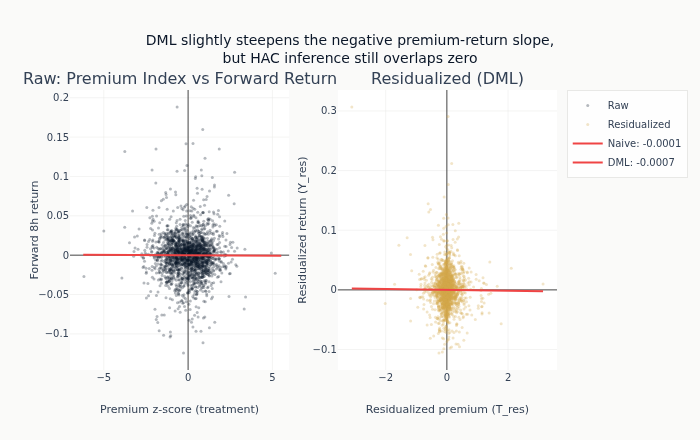

In [15]:
# Overlay regression lines showing naive vs DML slopes
x_range = np.linspace(T.min(), T.max(), 100)
fig.add_trace(
    go.Scatter(
        x=x_range,
        y=naive_effect * x_range,
        mode="lines",
        line=dict(color=COLORS["negative"], width=2),
        name=f"Naive: {naive_effect:.4f}",
    ),
    row=1,
    col=1,
)

if valid_res.sum() > 100:
    x_range_res = np.linspace(T_res[valid_res].min(), T_res[valid_res].max(), 100)
    fig.add_trace(
        go.Scatter(
            x=x_range_res,
            y=dml_effect * x_range_res,
            mode="lines",
            line=dict(color=COLORS["negative"], width=2),
            name=f"DML: {dml_effect:.4f}",
        ),
        row=1,
        col=2,
    )

fig.update_xaxes(title_text="Premium z-score (treatment)", row=1, col=1)
fig.update_yaxes(title_text="Forward 8h return", row=1, col=1)
fig.update_xaxes(title_text="Residualized premium (T_res)", row=1, col=2)
fig.update_yaxes(title_text="Residualized return (Y_res)", row=1, col=2)
fig.update_layout(
    height=440,
    title_text=(
        "DML slightly steepens the negative premium-return slope,<br>"
        "but HAC inference still overlaps zero"
    ),
    margin=dict(t=90, b=70, l=70, r=40),
)
fig.show()

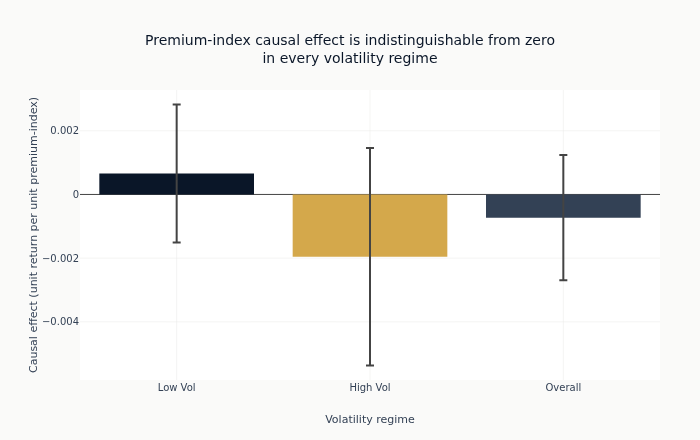

In [16]:
# Regime comparison
fig2 = go.Figure()
fig2.add_trace(
    go.Bar(
        x=["Low Vol", "High Vol", "Overall"],
        y=[effect_low, effect_high, dml_effect],
        error_y=dict(type="data", array=[1.96 * se_low_hac, 1.96 * se_high_hac, 1.96 * dml_se_hac]),
        marker_color=[COLORS["blue"], COLORS["amber"], COLORS["neutral"]],
    )
)
fig2.update_layout(
    title=(
        "Premium-index causal effect is indistinguishable from zero<br>in every volatility regime"
    ),
    xaxis_title="Volatility regime",
    yaxis_title="Causal effect (unit return per unit premium-index)",
    height=440,
    margin=dict(t=90, b=60, l=80, r=40),
)
fig2.show()

In [17]:
# Quantitative summary for takeaways
se_inflation_naive = se_naive_hac / se_naive_iid
se_inflation_dml = dml_se_hac / dml_se_iid
regime_ratio = effect_high / effect_low if effect_low != 0 else np.nan

print(f"HAC/IID SE inflation, naive: {se_inflation_naive:.1f}x, DML: {se_inflation_dml:.1f}x")
print(f"Confounding bias (naive vs DML): {bias_pct:+.1f}%")
print(f"Regime effect ratio (high/low vol): {regime_ratio:.2f}x")

HAC/IID SE inflation, naive: 2.0x, DML: 1.5x
Confounding bias (naive vs DML): +85.3%
Regime effect ratio (high/low vol): -2.98x


## Key Takeaways

1. **Premium z-score as causal treatment**: The standardized premium deviation
   captures funding rate mean-reversion dynamics with a clear economic mechanism.

2. **Confounding bias magnitude**: Comparing naive OLS to DML reveals the bias
   introduced by ignoring volatility and funding rate confounders. The HAC-corrected
   standard errors are substantially wider than IID estimates (see SE inflation
   ratios above), reflecting autocorrelation in 8-hour crypto returns.

3. **No regime heterogeneity in this sample**: regime stratification does not
   rescue the premium-return effect. Both the low- and high-volatility subgroup
   ATEs are statistically indistinguishable from zero, and the high-minus-low
   difference is not significant; the regime story does not survive the data.

4. **Refutation robustness**: Block permutation (preserving autocorrelation
   structure) provides a more conservative null distribution than random permutation.

**Next**: See [`05_momentum_causal_trading`](05_momentum_causal_trading.ipynb) for applying CATE to trading decisions.

## 11. Summary

In [18]:
# Consolidated results table
summary_rows = [
    ("Naive OLS", naive_effect, se_naive_hac, t_stat_naive, "n/a"),
    ("DML (overall)", dml_effect, dml_se_hac, dml_t_stat, f"{bias_pct:+.1f}%"),
    ("DML (low vol)", effect_low, se_low_hac, t_low, "n/a"),
    ("DML (high vol)", effect_high, se_high_hac, t_high, "n/a"),
]

summary_df = pl.DataFrame(
    {
        "Estimator": [r[0] for r in summary_rows],
        "Effect": [r[1] for r in summary_rows],
        "SE (HAC)": [r[2] for r in summary_rows],
        "t-stat": [r[3] for r in summary_rows],
        "Bias vs DML": [r[4] for r in summary_rows],
    }
)
summary_df

Estimator,Effect,SE (HAC),t-stat,Bias vs DML
str,f64,f64,f64,str
"""Naive OLS""",-0.000107,0.000291,-0.366833,"""n/a"""
"""DML (overall)""",-0.000729,0.001005,-0.725157,"""+85.3%"""
"""DML (low vol)""",0.000657,0.001106,0.593357,"""n/a"""
"""DML (high vol)""",-0.001957,0.001742,-1.123874,"""n/a"""


In [19]:
# Refutation and regime difference
refutation_str = (
    f"z={z_score:.2f}, permutation p={permutation_p:.4f}"
    if z_score is not None
    else "insufficient data"
)
print(f"Regime difference: {effect_diff:.4f} (t={t_diff:.2f})")
print(f"Block permutation refutation: {refutation_str}")

Regime difference: -0.0026 (t=-1.18)
Block permutation refutation: z=-2.47, permutation p=0.0099


**Interpretation**: The DML estimate removes confounding from volatility and
funding rate. The "Bias vs DML" column in the table above quantifies how much
volatility confounds the raw premium-return relationship. The regime
difference test indicates whether the premium effect varies meaningfully
between calm and volatile markets. Block permutation preserves short-range
autocorrelation, giving a more conservative null distribution than random
shuffling.